In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

data = pd.read_csv(url)

data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
print(data[V7])
print(data[V8])


NameError: name 'V7' is not defined

In [ ]:
data.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [ ]:
data['Class'].value_counts()

,count
Class,
0,284315
1,492


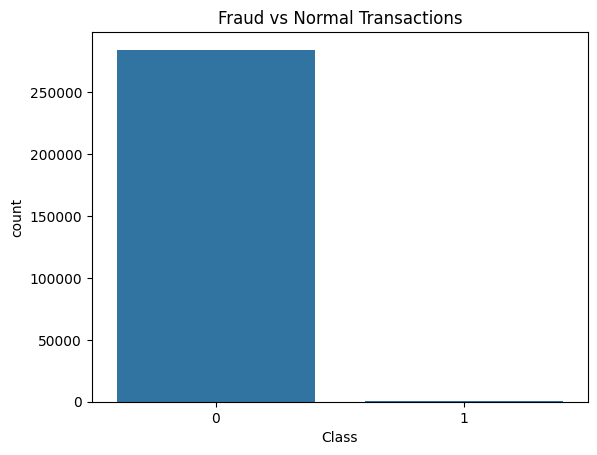

In [ ]:
sns.countplot(x='Class', data=data)
plt.title("Fraud vs Normal Transactions")
plt.show()

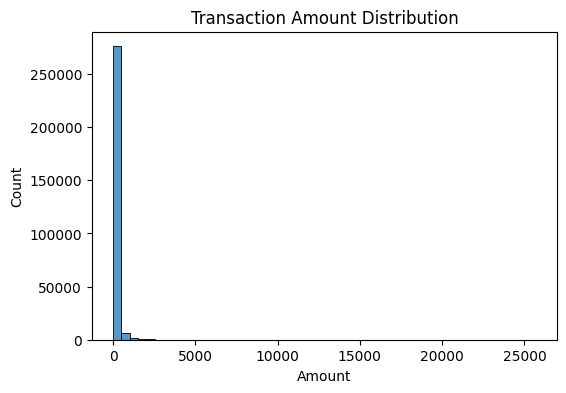

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(data['Amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

In [ ]:
fraud = data[data['Class'] == 1]
normal = data[data['Class'] == 0]

print("Fraud transactions:", len(fraud))
print("Normal transactions:", len(normal))

Fraud transactions: 492
Normal transactions: 284315


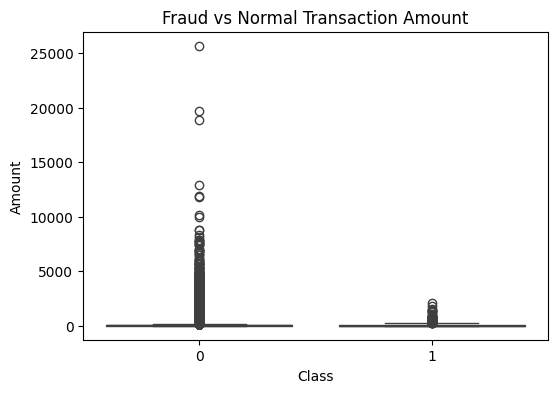

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Class', y='Amount', data=data)
plt.title("Fraud vs Normal Transaction Amount")
plt.show()

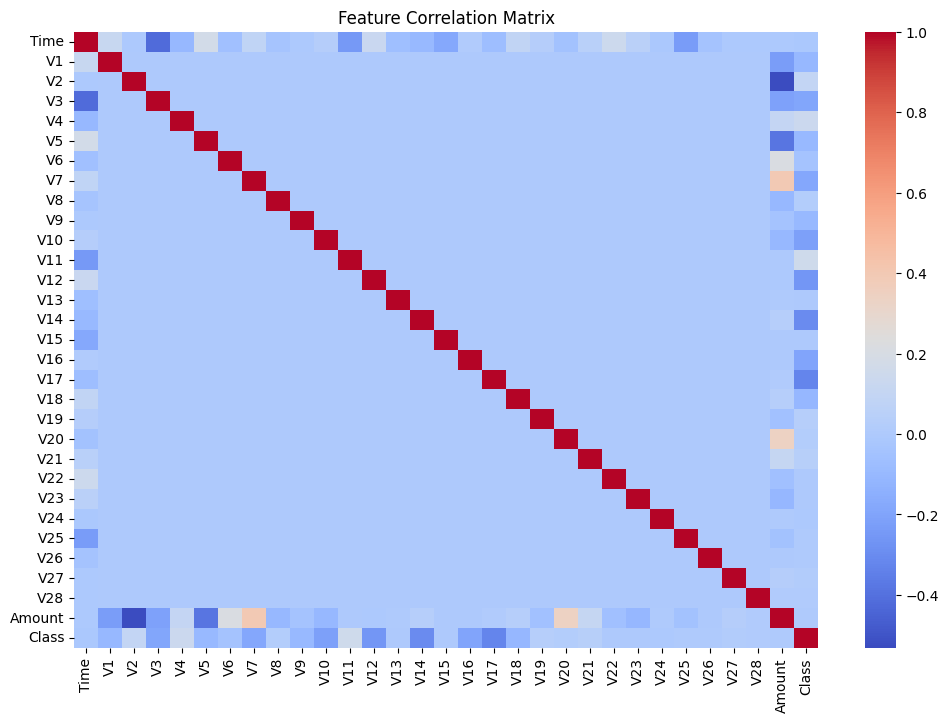

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

data['scaled_amount'] = scaler.fit_transform(data['Amount'].values.reshape(-1,1))
data['scaled_time'] = scaler.fit_transform(data['Time'].values.reshape(-1,1))

In [ ]:
data.drop(['Time','Amount'], axis=1, inplace=True)

In [ ]:
data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964,-1.996583
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475,-1.996583
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686,-1.996562
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534,-1.996562
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403,-1.996541


In [ ]:
X = data.drop('Class', axis=1)
y = data['Class']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(227845, 30)
(56962, 30)
(227845,)
(56962,)


In [ ]:
!pip install imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
sm = SMOTE(random_state=42)

X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [ ]:
print(y_train_res.value_counts())

Class
0    227451
1    227451
Name: count, dtype: int64


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
lr = LogisticRegression()

lr.fit(X_train_res, y_train_res)

LogisticRegression()

In [ ]:
lr_pred = lr.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, lr_pred))

Accuracy: 0.9745795442575752


In [ ]:
print(confusion_matrix(y_test, lr_pred))

[[55423  1441]
 [    7    91]]


In [ ]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.93      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_res, y_train_res)

KNeighborsClassifier()

In [ ]:
knn_pred = knn.predict(X_test)

In [ ]:
print("KNN Accuracy:", accuracy_score(y_test, knn_pred))

KNN Accuracy: 0.9981742214107651


In [ ]:
print(confusion_matrix(y_test, knn_pred))

[[56773    91]
 [   13    85]]


In [ ]:
print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.48      0.87      0.62        98

    accuracy                           1.00     56962
   macro avg       0.74      0.93      0.81     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt = DecisionTreeClassifier()

dt.fit(X_train_res, y_train_res)

DecisionTreeClassifier()

In [ ]:
dt_pred = dt.predict(X_test)

In [ ]:
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.9980513324672589


In [ ]:
print(confusion_matrix(y_test, dt_pred))

[[56774    90]
 [   21    77]]


In [ ]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.46      0.79      0.58        98

    accuracy                           1.00     56962
   macro avg       0.73      0.89      0.79     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train_res, y_train_res)

RandomForestClassifier(random_state=42)

In [ ]:
rf_pred = rf.predict(X_test)

In [ ]:
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.9995611109160493


In [ ]:
print(confusion_matrix(y_test, rf_pred))

[[56854    10]
 [   15    83]]


In [ ]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.89      0.85      0.87        98

    accuracy                           1.00     56962
   macro avg       0.95      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



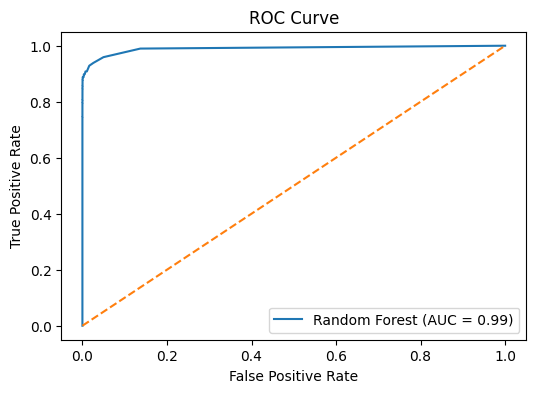

In [ ]:
from sklearn.metrics import roc_curve, auc

rf_probs = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, rf_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="Random Forest (AUC = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

In [ ]:
models = ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest']

accuracies = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, knn_pred),
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, rf_pred)
]

for model, acc in zip(models, accuracies):
    print(model, ":", acc)

Logistic Regression : 0.9745795442575752
KNN : 0.9981742214107651
Decision Tree : 0.9980513324672589
Random Forest : 0.9995611109160493


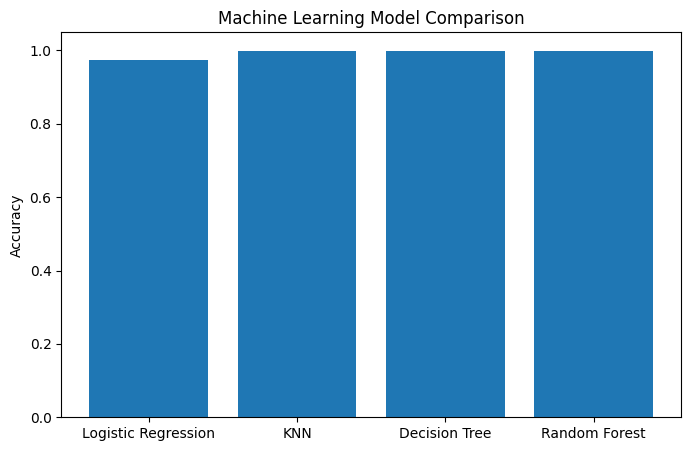

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.title("Machine Learning Model Comparison")
plt.ylabel("Accuracy")

plt.show()

In [ ]:
import pickle

with open("fraud_detection_model.pkl", "wb") as f:
    pickle.dump(rf, f)

In [ ]:
from google.colab import files
files.download("fraud_detection_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>